# TP3 - 1a : Modelo de referencia del interpolador

In [9]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'utils').exists():
    repo_root = repo_root.parent
if not (repo_root / 'utils').exists():
    raise RuntimeError('No se encontro la raiz del repositorio')
sys.path.insert(0, str(repo_root))

from TP3.model.reference_model import (
    InterpolatorConfig,
    design_coefficients,
    generate_stimulus,
    interpolate_polyphase_fixed,
    interpolate_zeros_fixed,
    polyphase_coefficients,
    export_hex
)

## Formatos y coeficientes

La entrada, los coeficientes y la salida son signed Q1.11. El producto conserva sus 24 bits y el acumulador agrega cuatro bits de guarda. El único resize con pérdida es el de salida: truncamiento de LSB y saturación signed, igual que `sat_trunc.sv`.

In [10]:
cfg = InterpolatorConfig()
h_float, h_quantized, h_integer = design_coefficients(cfg)
phases = polyphase_coefficients(h_integer, cfg)

print(f'Entrada/salida : Q({cfg.data_format.NB},{cfg.data_format.NBF})')
print(f'Producto       : Q({cfg.product_format.NB},{cfg.product_format.NBF})')
print(f'Acumulador     : Q({cfg.accumulator_format.NB},{cfg.accumulator_format.NBF})')
print(f'Coeficientes   : {h_integer.tolist()}')
print(f'Suma cuantizada: {h_integer.sum() / cfg.coefficient_format.scale:.6f}')
print('Fases [p, r]:\n', phases)

Entrada/salida : Q(12,11)
Producto       : Q(24,22)
Acumulador     : Q(28,22)
Coeficientes   : [-11, -44, -101, -88, 167, 740, 1462, 1971, 1971, 1462, 740, 167, -88, -101, -44, -11]
Suma cuantizada: 4.000000
Fases [p, r]:
 [[ -11  167 1971  -88]
 [ -44  740 1462 -101]
 [-101 1462  740  -44]
 [ -88 1971  167  -11]]


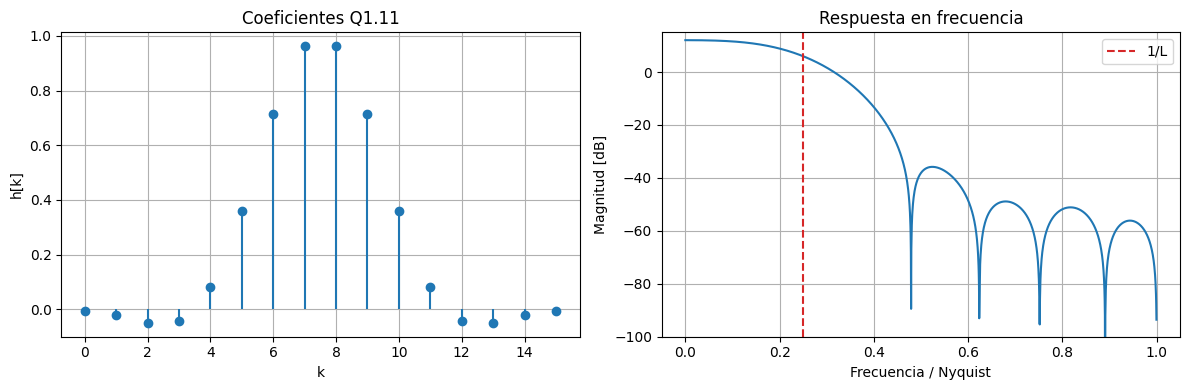

In [11]:
w, response = freqz(h_quantized, worN=2048)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stem(np.arange(cfg.taps), h_quantized, basefmt=' ')
axes[0].set(title='Coeficientes Q1.11', xlabel='k', ylabel='h[k]')
axes[0].grid(True)
axes[1].plot(w / np.pi, 20 * np.log10(np.maximum(np.abs(response), 1e-12)))
axes[1].axvline(1 / cfg.interpolation, color='tab:red', linestyle='--', label='1/L')
axes[1].set(title='Respuesta en frecuencia', xlabel='Frecuencia / Nyquist', ylabel='Magnitud [dB]', ylim=(-100, 15))
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()

## Equivalencia bit a bit

Se usa el estímulo común de 2000 muestras. La convolución completa produce $2000\,L+N-1=8015$ salidas, incluyendo la cola del filtro.

In [12]:
x_quantized, x_integer = generate_stimulus(cfg)
y_zeros = interpolate_zeros_fixed(x_integer, h_integer, cfg)
y_poly = interpolate_polyphase_fixed(x_integer, h_integer, cfg)

np.testing.assert_array_equal(y_zeros, y_poly)
print(f'Entradas: {len(x_integer)}')
print(f'Salidas : {len(y_zeros)}')
print(f'Diferencias bit a bit: {np.count_nonzero(y_zeros != y_poly)}')
print(f'Rango de salida entero: [{y_zeros.min()}, {y_zeros.max()}]')

Entradas: 2000
Salidas : 8015
Diferencias bit a bit: 0
Rango de salida entero: [-1021, 1005]


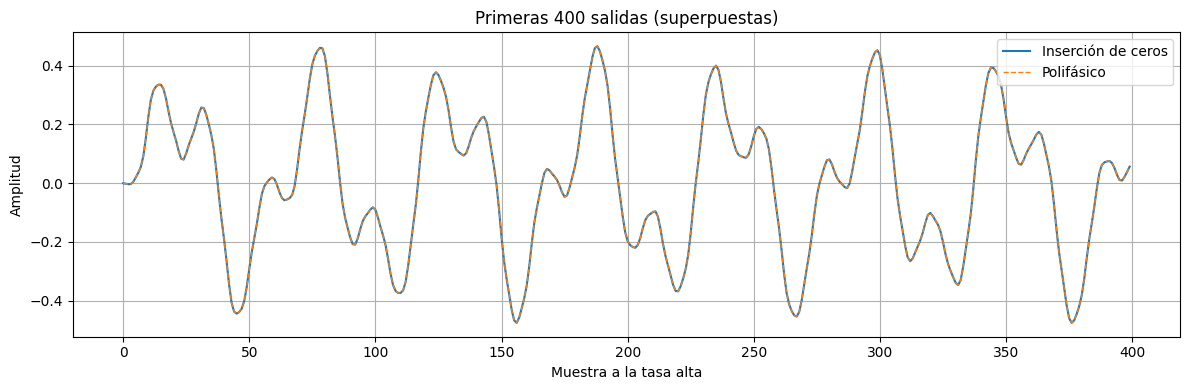

In [13]:
scale = cfg.output_format.scale
plt.figure(figsize=(12, 4))
plt.plot(y_zeros[:400] / scale, label='Inserción de ceros', linewidth=1.5)
plt.plot(y_poly[:400] / scale, '--', label='Polifásico', linewidth=1)
plt.title('Primeras 400 salidas (superpuestas)')
plt.xlabel('Muestra a la tasa alta')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()

## Vectores para RTL

La siguiente celda regenera los archivos hexadecimales. Los coeficientes del FIR directo se exportan como `h[k]`; los polifásicos se exportan primero por fase y luego por tap. La semilla del ruido está fijada para que todas las mediciones de potencia usen exactamente la misma actividad.

In [14]:
output_dir = repo_root / 'TP3' / 'model' / 'vectors'

paths = {
        'coefficients': output_dir / 'coefficients_q1_11.hex',
        'polyphase_coefficients': output_dir / 'coefficients_polyphase_q1_11.hex',
        'stimulus': output_dir / 'stimulus_q1_11.hex',
        'expected': output_dir / 'expected_q1_11.hex',
    }

export_hex(paths['coefficients'], h_integer, cfg.coefficient_format)
export_hex(paths['polyphase_coefficients'], phases.reshape(-1), cfg.coefficient_format)
export_hex(paths['stimulus'], x_integer, cfg.data_format)
export_hex(paths['expected'], y_zeros, cfg.output_format)

for name, path in paths.items():
    print(f'{name:24s}: {path}')

coefficients            : /home/dlugano/Fulgor/VLSI_2026/TP3/model/vectors/coefficients_q1_11.hex
polyphase_coefficients  : /home/dlugano/Fulgor/VLSI_2026/TP3/model/vectors/coefficients_polyphase_q1_11.hex
stimulus                : /home/dlugano/Fulgor/VLSI_2026/TP3/model/vectors/stimulus_q1_11.hex
expected                : /home/dlugano/Fulgor/VLSI_2026/TP3/model/vectors/expected_q1_11.hex
